# EVS-POT
Use a function to map the (DH0, n_sigma) to 1D and estimate the probability.


## Read and plot

In [33]:
!ls /cosma/home/do012/dc-he4/anisotropy-flamingo/data/analysis_all/

bf_mc_all.csv			  h0_mc_all.csv
bf_mc_all_scatter.csv		  h0_mc_all_full.csv
bf_mc_zcos.csv			  h0_mc_joint_all.csv
bf_truth.csv			  h0_mc_joint_scatter_all.csv
concatenated_fit_all.csv	  h0_mc_scatter.csv
concatenated_fit_all_mc.csv	  h0_mc_zcos.csv
concatenated_fit_all_scatter.csv  scatter_LX-T_added_scatter.csv
h0_angle_constraint_mc.csv	  scatter_LX-T.csv
h0_angle_constraint_scan.csv	  scatter_M-T.csv
h0_angle_constraints.csv	  scatter_YSZ-T_added_scatter.csv
h0_direct_compare.csv		  scatter_YSZ-T.csv
h0_direct_compare_scatter.csv


In [34]:
# Import necessary libraries
import pandas as pd
import numpy as np
from scipy.stats import genpareto
from scipy.special import erfinv
import math
import matplotlib.pyplot as plt
import clusterfit as cf
import clusterplot as cp
plt.style.use('./nice.mplstyle')

# Set percentile for EVS threshold
percentile = 95

def calculate_sigma_p_value(proj, target_value):
    median = np.median(proj)
    sigma_84th = np.percentile(proj, 84)
    sigma = sigma_84th - median
    sigma_deviation = np.abs((target_value - median) / sigma)
    p_value_sigma = 1 - math.erf(sigma_deviation / np.sqrt(2))
    return sigma_deviation, p_value_sigma

# Function to calculate EVT p-value
def calculate_evt_p_value(proj, target_value, percentile):
    # Determine the threshold
    threshold = np.percentile(proj, percentile)
    exceedances = proj[proj > threshold] - threshold  # Tail data

    # Fit GPD to the tail data
    params = genpareto.fit(exceedances)

    # Tail survival probability (proportion of data in the tail)
    tail_prob = np.sum(proj >= threshold) / len(proj)

    if target_value > threshold:
        # Conditional probability adjusted to match at the threshold
        p_value_evt = (1 - genpareto.cdf(target_value - threshold, *params)) * tail_prob
    else:
        # Empirical CDF for the bulk region
        p_value_evt = np.sum(proj >= target_value) / len(proj)

    # Transform to sigma (Gaussian equivalent deviation)
    sigma_evt = np.sqrt(2) * erfinv(1 - p_value_evt)

    return p_value_evt, sigma_evt


# The first projection function
def default_proj(y, n_sigma):
    return y - y / n_sigma


In [35]:
def __calc_and_plot():
    """ Interior function to avoid copy pasting the same procedure 100 times."""

    # Number of sigma deviation
    sigma_deviation, p_value_sigma = calculate_sigma_p_value(x, target_value)
    print(f"Number of std deviation: p={p_value_sigma:.3g}\\,({sigma_deviation:.3g}\\sigma)")

    # Frequentist
    p_value_freq = np.sum(x > target_value)/len(x)
    n_sigma_freq = cf.n_sigma1d(p_value_freq)
    print(f'Frequentist:{np.sum(x > target_value)}/{len(x)} p={p_value_freq} ({n_sigma_freq})')

    # Calculate EVT p-value and sigma deviation
    p_value_evt, sigma_evt = calculate_evt_p_value(x, target_value, percentile=percentile)
    print(f"EVT p-value: p={p_value_evt:.3g}\\,({sigma_evt:.3g}\\sigma)")

    # Plotting results
    fig = plt.figure(figsize=(5, 3))
    plt.hist(x, bins=30, density=True, alpha=0.6, color='#d95f02', label='FLAMINGO')

    # Fit a GPD distribution
    threshold = np.percentile(x, percentile)
    exceedances = x[x > threshold] - threshold
    params = genpareto.fit(exceedances)
    shape, loc, scale = params

    # Plot fitted distribution
    x_vals = np.linspace(threshold, x.max(), 100)
    gpd_pdf = genpareto.pdf(x_vals - threshold, shape, loc, scale) * (1 - percentile / 100)
    plt.axvline(target_value, color='red', linestyle='-', label='Migkas+21')
    plt.plot(x_vals[1:], gpd_pdf[1:], color='g', label='Fitted GPD (Tail)')
    plt.axvline(threshold, color='blue', linestyle='--', label='Threshold (90th Percentile)')

    # Annotate the plot
    plt.annotate(f'p={p_value_evt:.2g}', 
                xy=(target_value, 0.002), xycoords='data',
                xytext=(target_value - 100, 0.002), textcoords='data',
                arrowprops=dict(arrowstyle='->,head_width=.15', color='red'),
                horizontalalignment='right', verticalalignment='center', color='red')

    plt.xlabel('$x$')
    plt.ylabel('Density')
    plt.legend(fontsize=9)

    return fig

    
def __calc_and_plot_small():
    """ Interior function to avoid copy pasting the same procedure 100 times."""

    # Number of sigma deviation
    sigma_deviation, p_value_sigma = calculate_sigma_p_value(x, target_value)
    print(f"Number of std deviation: p={p_value_sigma:.3g}\\,({sigma_deviation:.3g}\\sigma)")

    # Calculate EVT p-value and sigma deviation
    p_value_evt, sigma_evt = calculate_evt_p_value(x, target_value, percentile=percentile)
    print(f"EVT p-value: p={p_value_evt:.3g}\\,({sigma_evt:.3g}\\sigma)")

    # Fit a GPD distribution
    threshold = np.percentile(x, percentile)
    exceedances = x[x > threshold] - threshold
    params = genpareto.fit(exceedances)
    shape, loc, scale = params

    # Fitted distribution
    x_vals = np.linspace(threshold, x.max(), 100)
    gpd_pdf = genpareto.pdf(x_vals - threshold, shape, loc, scale) * (1 - percentile / 100)

    # Plot
    fig, ax = cp._small_evs_(distribution=x,
                            target_value=target_value,
                            x_vals=x_vals,
                            gpd_pdf=gpd_pdf,
                            threshold=threshold,
                            percentile=percentile,
                            sigma_evt=sigma_evt, color='#d95f02')

    return fig

## Lx-T
z = 0.07, 0.10

In [36]:
# Load the data
data = pd.read_csv('../data/analysis_all/bf_mc_all_scatter.csv')

# Filter data for zmax = 0.07
zmask = data['zmax'] == 0.07
seg = data[zmask][data['scaling_relation'] == 'LX-T'][['ubf', 'ubf_err_lower']]

# Calculate the projection values
x = seg['ubf'].values - seg['ubf_err_lower'].values

# Define the target value
target_value = 1100 - 410

/tmp/ipykernel_978775/3646976485.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  seg = data[zmask][data['scaling_relation'] == 'LX-T'][['ubf', 'ubf_err_lower']]


Number of std deviation: p=0.0282\,(2.2\sigma)


EVT p-value: p=0.00812\,(2.65\sigma)


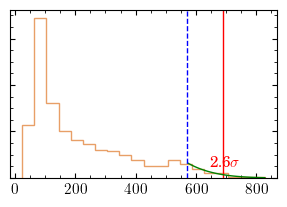

In [37]:
fig = __calc_and_plot_small()
plt.savefig(f'./to_paper/evs_bulk_flow_L_z0.07_scatter.pdf', bbox_inches='tight')   # save the figure
plt.show()

In [38]:
# Load the data
data = pd.read_csv('../data/analysis_all/bf_mc_all_scatter.csv')

# Filter data for zmax = 0.10
zmask = data['zmax'] == 0.10
seg = data[zmask][data['scaling_relation'] == 'LX-T'][['ubf', 'ubf_err_lower']]

# Calculate the projection values
x = seg['ubf'].values - seg['ubf_err_lower'].values

# Define the target value
target_value = 1080 - 380

/tmp/ipykernel_978775/1713371179.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  seg = data[zmask][data['scaling_relation'] == 'LX-T'][['ubf', 'ubf_err_lower']]


Number of std deviation: p=0.025\,(2.24\sigma)
EVT p-value: p=0.00661\,(2.72\sigma)


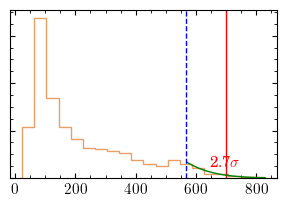

In [39]:
fig = __calc_and_plot_small()
plt.savefig(f'./to_paper/evs_bulk_flow_L_z0.10_scatter.pdf', bbox_inches='tight')   # save the figure
plt.show()

## Ysz-T
z = 0.07, 0.10

In [40]:
# Load the data
data = pd.read_csv('../data/analysis_all/bf_mc_all_scatter.csv')

# Filter data for zmax = 0.07
zmask = data['zmax'] == 0.07
seg = data[zmask][data['scaling_relation'] == 'YSZ-T'][['ubf', 'ubf_err_lower']]

# Calculate the projection values
x = seg['ubf'].values - seg['ubf_err_lower'].values

# Define the target value
target_value = 1060 - 390

/tmp/ipykernel_978775/392055772.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  seg = data[zmask][data['scaling_relation'] == 'YSZ-T'][['ubf', 'ubf_err_lower']]


Number of std deviation: p=1.1e-09\,(6.09\sigma)
EVT p-value: p=0.000577\,(3.44\sigma)


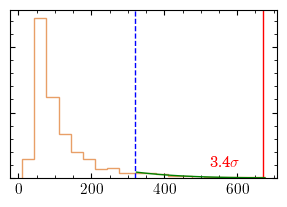

In [41]:
fig = __calc_and_plot_small()
plt.savefig(f'./to_paper/evs_bulk_flow_Y_z0.07_scatter.pdf', bbox_inches='tight')   # save the figure
plt.show()

In [42]:
# Load the data
data = pd.read_csv('../data/analysis_all/bf_mc_all_scatter.csv')

# Filter data for zmax = 0.10
zmask = data['zmax'] == 0.10
seg = data[zmask][data['scaling_relation'] == 'YSZ-T'][['ubf', 'ubf_err_lower']]

# Calculate the projection values
x = seg['ubf'].values - seg['ubf_err_lower'].values

# Define the target value
target_value = 1020 - 380

/tmp/ipykernel_978775/4045150868.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  seg = data[zmask][data['scaling_relation'] == 'YSZ-T'][['ubf', 'ubf_err_lower']]


Number of std deviation: p=7.31e-09\,(5.78\sigma)
EVT p-value: p=0.0011\,(3.26\sigma)


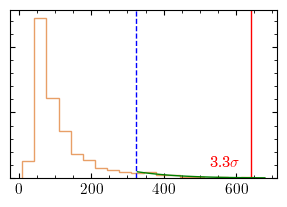

In [43]:
fig = __calc_and_plot_small()
plt.savefig(f'./to_paper/evs_bulk_flow_Y_z0.10_scatter.pdf', bbox_inches='tight')   # save the figure
plt.show()

## Joint of LT, YT

In [44]:
# Load the data
data = pd.read_csv('../data/analysis_all/bf_mc_all_scatter.csv')

# Filter data for zmax = 0.07
zmask = data['zmax'] == 0.07
uLT = data[zmask][data['scaling_relation'] == 'LX-T'][['Lightcone', 'ubf', 'ubf_err_lower', 'vlat', 'vlon']]
uYT = data[zmask][data['scaling_relation'] == 'YSZ-T'][['Lightcone', 'ubf', 'ubf_err_lower', 'vlat', 'vlon']]

# Merge the data on Lightcone
u = pd.merge(left=uLT, right=uYT, on='Lightcone', suffixes=('_LT', '_YT'))

# Calculate the projection values
theta = cf.angular_separation(u['vlon_LT'].values, u['vlat_LT'].values,
    u['vlon_YT'].values, u['vlon_YT'].values) * np.pi/180
x = (u['ubf_LT'].values - u['ubf_err_lower_LT'].values) * np.cos(theta / 2) +\
    (u['ubf_YT'].values - u['ubf_err_lower_YT'].values) * np.cos(theta / 2)
x /= 2

# Define the target value
th = cf.angular_separation(318, -5, 254, -17) * np.pi/180
target_value = (1100 - 410) * np.cos(th / 2) + (1060 - 390) * np.cos(th / 2)
target_value /= 2

/tmp/ipykernel_978775/3997380869.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  uLT = data[zmask][data['scaling_relation'] == 'LX-T'][['Lightcone', 'ubf', 'ubf_err_lower', 'vlat', 'vlon']]
/tmp/ipykernel_978775/3997380869.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  uYT = data[zmask][data['scaling_relation'] == 'YSZ-T'][['Lightcone', 'ubf', 'ubf_err_lower', 'vlat', 'vlon']]


Number of std deviation: p=2.05e-06\,(4.75\sigma)
Frequentist:1/1650 p=0.0006060606060606061 (3.4288875364309845)
EVT p-value: p=0.000359\,(3.57\sigma)


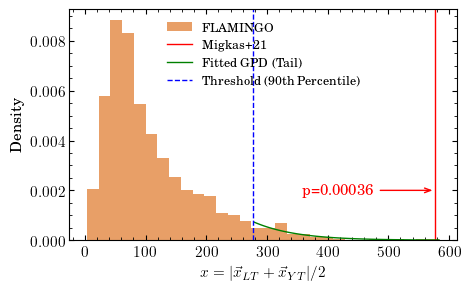

In [45]:
fig = __calc_and_plot()
plt.xlabel(r'$x=|\vec{x}_{LT} + \vec{x}_{YT}|/2$')
plt.savefig(f'./to_paper/evs_bulk_flow_joint_scatter_z0.07.pdf', bbox_inches='tight')   # save the figure
plt.show()

## Joint of LT YT

In [46]:
# Load the data
data = pd.read_csv('../data/analysis_all/bf_mc_all_scatter.csv')

# Filter data for zmax = 0.10
zmask = data['zmax'] == 0.10
uLT = data[zmask][data['scaling_relation'] == 'LX-T'][['Lightcone', 'ubf', 'ubf_err_lower', 'vlat', 'vlon']]
uYT = data[zmask][data['scaling_relation'] == 'YSZ-T'][['Lightcone', 'ubf', 'ubf_err_lower', 'vlat', 'vlon']]

# Merge the data on Lightcone
u = pd.merge(left=uLT, right=uYT, on='Lightcone', suffixes=('_LT', '_YT'))

# Calculate the projection values
theta = cf.angular_separation(u['vlon_LT'].values, u['vlat_LT'].values,
    u['vlon_YT'].values, u['vlon_YT'].values) * np.pi/180
x = (u['ubf_LT'].values - u['ubf_err_lower_LT'].values) * np.cos(theta / 2) +\
    (u['ubf_YT'].values - u['ubf_err_lower_YT'].values) * np.cos(theta / 2)
x /= 2

# Define the target value
th = cf.angular_separation(257, -28, 322, -13) * np.pi/180
target_value = (1080-380) * np.cos(th / 2) + (1020-380) * np.cos(th / 2)
target_value /= 2

/tmp/ipykernel_978775/515186172.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  uLT = data[zmask][data['scaling_relation'] == 'LX-T'][['Lightcone', 'ubf', 'ubf_err_lower', 'vlat', 'vlon']]
/tmp/ipykernel_978775/515186172.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  uYT = data[zmask][data['scaling_relation'] == 'YSZ-T'][['Lightcone', 'ubf', 'ubf_err_lower', 'vlat', 'vlon']]


Number of std deviation: p=1.93e-06\,(4.76\sigma)
Frequentist:1/1663 p=0.0006013229104028864 (3.431017002324772)
EVT p-value: p=0.000375\,(3.56\sigma)


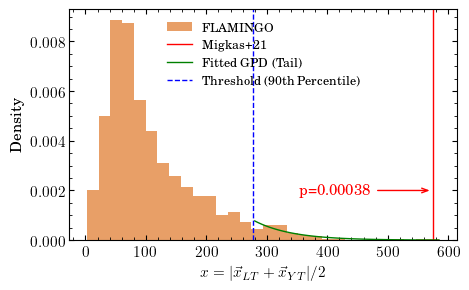

In [47]:
fig = __calc_and_plot()
plt.xlabel(r'$x=|\vec{x}_{LT} + \vec{x}_{YT}|/2$')
plt.savefig(f'./to_paper/evs_bulk_flow_joint_scatter_z0.10.pdf', bbox_inches='tight')   # save the figure
plt.show()